# Lecture 14, Notebook 04: GP-based value-function iteration

**Script reference:** Chapter 9, §9.8.  
**Purpose:** value-function iteration for the one-state stochastic growth model using a Gaussian-process surrogate.

This version keeps the notebook focused on the dynamic-programming object.  The previous separable two-dimensional benchmark has been removed from the main workflow because it was a GP interpolation exercise, not a value-function-iteration exercise.  Multidimensional ASGP results should be discussed in the chapter as literature and active-subspace material, not as something validated by a separable toy target.

The notebook produces three figure families that can be used in the script:

1. 1D GP-VFI convergence and value-function uncertainty.
2. Same-budget 1D active enrichment versus a fixed Latin-hypercube design.
3. A deterministic full-depreciation Brock--Mirman verification against the closed-form solution.


In [1]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 12345
SAVE_FIGURES = True
FIG_DIR = "fig_gp_vfi"


## 1. Model and numerical settings

The baseline model is the one-state stochastic growth problem

\[
V(k)=\max_{0<c<\bar c(k)}\left\{\log c+\beta \mathbb E_z[V(k')]\right\},
\qquad
k'=(1-\delta)k+z A k^\alpha-c.
\]

The expectation is approximated by Gauss--Hermite quadrature.  Since the state is positive and the value function is close to logarithmic, the GP is fitted on the transformed input \(x=\log k\).  This small change makes the surrogate much more stationary and removes much of the boundary behavior near low capital.


In [2]:
from __future__ import annotations

from dataclasses import dataclass, replace
from pathlib import Path
from typing import Optional
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_solve
from scipy.optimize import minimize_scalar
from scipy.special import roots_hermite
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
from sklearn.exceptions import ConvergenceWarning

np.random.seed(SEED)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
plt.rcParams.update({"font.size": 12})

if RUN_MODE not in {"smoke", "teaching", "production"}:
    raise ValueError("RUN_MODE must be 'smoke', 'teaching', or 'production'.")

SETTINGS = {
    "smoke": dict(
        n_train_main=12, main_iter=50, experiment_iter=55, verification_iter=180,
        reference_n=22, verification_n=14, hp_opt_iters=5, n_restarts=0,
        k_eval_n=160, tol=1e-2,
    ),
    "teaching": dict(
        n_train_main=16, main_iter=90, experiment_iter=95, verification_iter=130,
        reference_n=36, verification_n=20, hp_opt_iters=8, n_restarts=1,
        k_eval_n=260, tol=3e-4,
    ),
    "production": dict(
        n_train_main=24, main_iter=170, experiment_iter=160, verification_iter=220,
        reference_n=50, verification_n=28, hp_opt_iters=12, n_restarts=2,
        k_eval_n=350, tol=1e-4,
    ),
}
CFG = SETTINGS[RUN_MODE]

fig_dir = Path(FIG_DIR)
if SAVE_FIGURES:
    fig_dir.mkdir(parents=True, exist_ok=True)

print(f"RUN_MODE = {RUN_MODE}")
print(f"Figures saved to: {fig_dir.resolve() if SAVE_FIGURES else '[not saved]'}")


RUN_MODE = smoke
Figures saved to: /mnt/data/fig_gp_vfi


In [3]:
@dataclass(frozen=True)
class GrowthModel:
    alpha: float = 0.36
    beta: float = 0.96
    delta: float = 0.10
    A: float = 1.0
    sigma: float = 0.04
    k_min: float = 0.20
    k_max: float = 3.00
    n_quad: int = 5
    name: str = "partial-depreciation stochastic growth"


def quadrature_nodes(model: GrowthModel) -> tuple[np.ndarray, np.ndarray]:
    """Gauss--Hermite nodes for z = exp(sigma * epsilon), epsilon ~ N(0,1)."""
    if model.sigma == 0.0 or model.n_quad <= 1:
        return np.array([1.0]), np.array([1.0])
    nodes, weights = roots_hermite(model.n_quad)
    z_nodes = np.exp(model.sigma * np.sqrt(2.0) * nodes)
    z_weights = weights / np.sqrt(np.pi)
    return z_nodes, z_weights


def initial_value(k: np.ndarray | float, model: GrowthModel) -> np.ndarray:
    """Simple concave initial guess used for the generic VFI runs."""
    k = np.asarray(k, dtype=float)
    return np.log(model.A * k ** model.alpha) / (1.0 - model.beta)


base_model = GrowthModel()
z_nodes, z_weights = quadrature_nodes(base_model)
print(base_model)
print(f"Quadrature z nodes  : {np.array2string(z_nodes, precision=5)}")
print(f"Quadrature weights  : {np.array2string(z_weights, precision=5)}")
print(f"sum weights         : {z_weights.sum():.8f}")
print(f"quadrature E[z]     : {np.dot(z_weights, z_nodes):.8f}")


GrowthModel(alpha=0.36, beta=0.96, delta=0.1, A=1.0, sigma=0.04, k_min=0.2, k_max=3.0, n_quad=5, name='partial-depreciation stochastic growth')
Quadrature z nodes  : [0.89201 0.94722 1.      1.05572 1.12106]
Quadrature weights  : [0.01126 0.22208 0.53333 0.22208 0.01126]
sum weights         : 1.00000000
quadrature E[z]     : 1.00080032


## 2. Gaussian-process surrogate and diagnostics

The GP is the interpolation layer inside the Bellman iteration.  We use a Matérn-\(5/2\) kernel in \(\log k\) space.  Hyperparameters are optimized only during the first few VFI iterations and then frozen, which gives stable and fast iterations while preserving the marginal-likelihood fit early in the run.

The leave-one-out RMSE is computed from the fitted GP Cholesky factor, so it is essentially free once the GP has been fitted.


In [4]:
def to_feature(k: np.ndarray | float) -> np.ndarray:
    """Map positive capital to the GP input feature x = log(k)."""
    k_arr = np.asarray(k, dtype=float).reshape(-1, 1)
    if np.any(k_arr <= 0):
        raise ValueError("Capital values must be strictly positive.")
    return np.log(k_arr)


def make_kernel() -> ConstantKernel:
    return ConstantKernel(1.0, (1e-2, 1e2)) * Matern(
        length_scale=0.75,
        length_scale_bounds=(0.20, 5.0),
        nu=2.5,
    )


def fit_gp(
    k_train: np.ndarray,
    y_train: np.ndarray,
    *,
    kernel=None,
    optimize: bool = True,
    n_restarts: int = 0,
    alpha_nugget: float = 1e-7,
) -> GaussianProcessRegressor:
    """Fit a GP to Bellman labels as a function of log capital."""
    if kernel is None:
        kernel = make_kernel()
    gp = GaussianProcessRegressor(
        kernel=kernel,
        optimizer="fmin_l_bfgs_b" if optimize else None,
        n_restarts_optimizer=n_restarts if optimize else 0,
        normalize_y=True,
        alpha=alpha_nugget,
        random_state=SEED,
    )
    gp.fit(to_feature(k_train), np.asarray(y_train, dtype=float))
    return gp


def gp_predict(gp: GaussianProcessRegressor, k: np.ndarray | float, *, return_std: bool = False):
    """Predict with a GP that was fitted in log-capital coordinates."""
    return gp.predict(to_feature(k), return_std=return_std)


def gp_loo_rmse(gp: GaussianProcessRegressor, k_train: np.ndarray, y_train: np.ndarray) -> float:
    """Fast leave-one-out RMSE for a fitted sklearn GP."""
    y_train = np.asarray(y_train, dtype=float).ravel()
    n = len(y_train)
    if n < 3:
        return float("nan")
    K_inv = cho_solve((gp.L_, True), np.eye(n), check_finite=False)
    diag_inv = np.maximum(np.diag(K_inv), 1e-14)
    y_mean = np.asarray(getattr(gp, "_y_train_mean", 0.0)).ravel()[0]
    y_std = np.asarray(getattr(gp, "_y_train_std", 1.0)).ravel()[0]
    y_norm = (y_train - y_mean) / y_std
    loo_norm = y_norm - gp.alpha_.ravel() / diag_inv
    loo_pred = loo_norm * y_std + y_mean
    return float(np.sqrt(np.mean((loo_pred - y_train) ** 2)))


def savefig(name: str):
    if SAVE_FIGURES:
        path = fig_dir / name
        plt.savefig(path, bbox_inches="tight")
        print(f"saved: {path}")


## 3. Bellman oracle and GP-VFI loop

Each Bellman label is one scalar nonlinear program in consumption.  The expensive object in larger applications is exactly this oracle evaluation.  The GP controls how many such labels we need and gives a diagnostic posterior standard deviation on the state domain.


In [5]:
def bellman_objective(
    c: float,
    k: float,
    gp: GaussianProcessRegressor,
    model: GrowthModel,
    z_nodes: np.ndarray,
    z_weights: np.ndarray,
) -> float:
    """Negative Bellman RHS; minimize this to maximize the Bellman RHS."""
    if c <= 0:
        return 1e100
    resources = (1.0 - model.delta) * k + z_nodes * model.A * k ** model.alpha
    k_next = resources - c
    if np.any(k_next <= 0):
        return 1e100
    k_next = np.clip(k_next, model.k_min, model.k_max)
    V_next = gp_predict(gp, k_next)
    expected_value = float(np.dot(z_weights, V_next.ravel()))
    return -(np.log(c) + model.beta * expected_value)


def solve_bellman_point(
    k: float,
    gp: GaussianProcessRegressor,
    model: GrowthModel,
    z_nodes: np.ndarray,
    z_weights: np.ndarray,
    *,
    xatol: float = 1e-8,
) -> tuple[float, float]:
    """Solve the Bellman maximization at one capital value."""
    resources = (1.0 - model.delta) * k + z_nodes * model.A * k ** model.alpha
    c_low = 1e-10
    c_high = max(c_low * 10.0, 0.999999 * float(np.min(resources)))
    result = minimize_scalar(
        bellman_objective,
        bounds=(c_low, c_high),
        args=(k, gp, model, z_nodes, z_weights),
        method="bounded",
        options={"xatol": xatol},
    )
    if not result.success:
        raise RuntimeError(f"Bellman solve failed at k={k:.6g}: {result.message}")
    return -float(result.fun), float(result.x)


def run_gp_vfi(
    k_train_init: np.ndarray,
    model: GrowthModel,
    *,
    label: str,
    max_iter: int,
    tol: float,
    hp_opt_iters: int,
    n_restarts: int = 0,
    adaptive: bool = False,
    add_every: int = 10,
    n_add: int = 1,
    max_points: Optional[int] = None,
    candidate_grid: Optional[np.ndarray] = None,
    min_spacing: float = 0.05,
    verbose: bool = False,
) -> dict:
    """Run GP value-function iteration on a fixed or adaptively enriched 1D design."""
    z_nodes_local, z_weights_local = quadrature_nodes(model)
    k_train = np.sort(np.asarray(k_train_init, dtype=float).ravel())
    V_old = initial_value(k_train, model)
    gp = fit_gp(k_train, V_old, optimize=True, n_restarts=n_restarts)

    if max_points is None:
        max_points = len(k_train)
    if candidate_grid is None:
        candidate_grid = np.linspace(model.k_min, model.k_max, 400)

    history = []
    added_points = []

    if verbose:
        print(f"\n{label}: n0={len(k_train)}, max_iter={max_iter}, tol={tol:g}")
        print(f"{'iter':>4s} {'points':>6s} {'VFI err':>12s} {'LOO RMSE':>12s}")
        print("-" * 42)

    for it in range(1, max_iter + 1):
        V_new = np.empty_like(k_train)
        c_new = np.empty_like(k_train)
        for i, k in enumerate(k_train):
            V_new[i], c_new[i] = solve_bellman_point(k, gp, model, z_nodes_local, z_weights_local)

        scale = max(np.ptp(V_old), 1.0)
        err = float(np.max(np.abs(V_new - V_old)) / scale)

        optimize = it <= hp_opt_iters
        gp = fit_gp(
            k_train,
            V_new,
            kernel=gp.kernel_,
            optimize=optimize,
            n_restarts=n_restarts,
        )

        if adaptive and (it % add_every == 0) and len(k_train) < max_points:
            for _ in range(min(n_add, max_points - len(k_train))):
                _, std = gp_predict(gp, candidate_grid, return_std=True)
                interior_weight = 0.25 + 0.75 * np.sin(
                    np.pi * (candidate_grid - model.k_min) / (model.k_max - model.k_min)
                )
                score = std * interior_weight
                distance = np.min(np.abs(candidate_grid[:, None] - k_train[None, :]), axis=1)
                score[distance < min_spacing] = -np.inf
                if not np.any(np.isfinite(score)):
                    break
                k_new = float(candidate_grid[int(np.argmax(score))])
                V_new_point, _ = solve_bellman_point(k_new, gp, model, z_nodes_local, z_weights_local)
                k_train = np.r_[k_train, k_new]
                V_new = np.r_[V_new, V_new_point]
                order = np.argsort(k_train)
                k_train = k_train[order]
                V_new = V_new[order]
                added_points.append(k_new)
            gp = fit_gp(k_train, V_new, kernel=gp.kernel_, optimize=False)

        loo = gp_loo_rmse(gp, k_train, V_new)
        history.append({"iter": it, "error": err, "points": len(k_train), "loo_rmse": loo})

        if verbose and (it <= 3 or it % 10 == 0 or err < tol):
            print(f"{it:4d} {len(k_train):6d} {err:12.4e} {loo:12.4e}")

        V_old = V_new.copy()
        if err < tol and (not adaptive or len(k_train) >= max_points):
            break

    return {
        "label": label,
        "model": model,
        "gp": gp,
        "k_train": k_train,
        "V_train": V_old,
        "history": history,
        "iterations": it,
        "added_points": np.asarray(added_points),
        "converged": bool(history[-1]["error"] < tol),
    }


def bellman_residual_grid(result: dict, k_grid: np.ndarray) -> np.ndarray:
    """Compute T[V](k)-V(k) on a validation grid."""
    gp = result["gp"]
    model = result["model"]
    z_nodes_local, z_weights_local = quadrature_nodes(model)
    tv = np.empty_like(k_grid, dtype=float)
    for i, k in enumerate(k_grid):
        tv[i], _ = solve_bellman_point(float(k), gp, model, z_nodes_local, z_weights_local)
    return tv - gp_predict(gp, k_grid).ravel()


def policy_from_gp(result: dict, k_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return value, consumption, and deterministic expected-shock k' policy on a grid."""
    gp = result["gp"]
    model = result["model"]
    z_nodes_local, z_weights_local = quadrature_nodes(model)
    V = np.empty_like(k_grid, dtype=float)
    c = np.empty_like(k_grid, dtype=float)
    for i, k in enumerate(k_grid):
        V[i], c[i] = solve_bellman_point(float(k), gp, model, z_nodes_local, z_weights_local)
    z_mean = float(np.dot(z_weights_local, z_nodes_local))
    k_next = (1.0 - model.delta) * k_grid + z_mean * model.A * k_grid ** model.alpha - c
    return V, c, k_next


def history_array(result: dict, key: str) -> np.ndarray:
    return np.array([row[key] for row in result["history"]], dtype=float)


def centered_difference(y: np.ndarray, reference: np.ndarray) -> np.ndarray:
    """Remove the mean level difference to compare value-function shape."""
    diff = np.asarray(y, dtype=float).ravel() - np.asarray(reference, dtype=float).ravel()
    return diff - diff.mean()


## 4. Baseline 1D GP-VFI run

This is the object the chapter should use as the core hands-on example: a Bellman iteration with GP interpolation, posterior uncertainty, LOO diagnostics, and policy recovery.


In [6]:
k_train_main = np.linspace(base_model.k_min, base_model.k_max, CFG["n_train_main"])
main_result = run_gp_vfi(
    k_train_main,
    base_model,
    label="baseline 1D GP-VFI",
    max_iter=CFG["main_iter"],
    tol=CFG["tol"],
    hp_opt_iters=CFG["hp_opt_iters"],
    n_restarts=CFG["n_restarts"],
    verbose=True,
)

final_err = history_array(main_result, "error")[-1]
final_loo = history_array(main_result, "loo_rmse")[-1]
print(f"\nFinal iteration: {main_result['iterations']} | converged={main_result['converged']}")
print(f"Final relative VFI error: {final_err:.3e}")
print(f"Final LOO RMSE:           {final_loo:.3e}")
print(f"Learned kernel:           {main_result['gp'].kernel_}")



baseline 1D GP-VFI: n0=12, max_iter=50, tol=0.01
iter points      VFI err     LOO RMSE
------------------------------------------
   1     12   3.4364e-01   6.3480e-01
   2     12   2.5681e-01   1.9481e-01
   3     12   1.9672e-01   1.0803e-01


  10     12   2.8414e-02   3.1289e-02
  20     12   1.9058e-02   3.1023e-02


  30     12   1.2671e-02   3.1022e-02
  36     12   9.9180e-03   3.1022e-02

Final iteration: 36 | converged=True
Final relative VFI error: 9.918e-03
Final LOO RMSE:           3.102e-02
Learned kernel:           2.14**2 * Matern(length_scale=5, nu=2.5)


saved: fig_gp_vfi/gp_vfi_main_1d.pdf


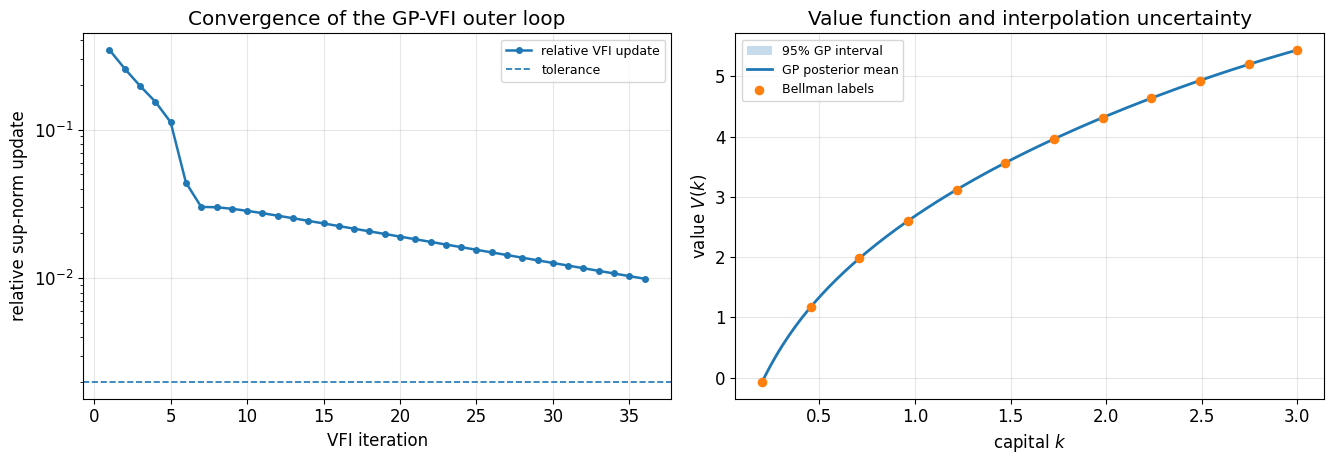

In [7]:
k_eval = np.linspace(base_model.k_min, base_model.k_max, CFG["k_eval_n"])
V_mean, V_std = gp_predict(main_result["gp"], k_eval, return_std=True)
errors = history_array(main_result, "error")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

ax = axes[0]
ax.semilogy(np.arange(1, len(errors) + 1), errors, "o-", lw=1.8, ms=4, label="relative VFI update")
ax.axhline(min(CFG["tol"], 2e-3), ls="--", lw=1.2, label="tolerance")
ax.set_xlabel("VFI iteration")
ax.set_ylabel("relative sup-norm update")
ax.set_title("Convergence of the GP-VFI outer loop")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

ax = axes[1]
ax.fill_between(k_eval, V_mean - 1.96 * V_std, V_mean + 1.96 * V_std, alpha=0.25, label="95% GP interval")
ax.plot(k_eval, V_mean, lw=2.0, label="GP posterior mean")
ax.scatter(main_result["k_train"], main_result["V_train"], s=35, zorder=4, label="Bellman labels")
ax.set_xlabel("capital $k$")
ax.set_ylabel("value $V(k)$")
ax.set_title("Value function and interpolation uncertainty")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
savefig("gp_vfi_main_1d.pdf")
plt.show()


## 5. Few versus more Bellman design points

Before discussing active learning, it is useful to show the basic sample-efficiency mechanism: with too few Bellman labels the GP is uncertain between labels; with more labels, the posterior interval and the approximation error shrink.


In [8]:
print("Running reference, few-point, and more-point designs...")
reference_result = run_gp_vfi(
    np.linspace(base_model.k_min, base_model.k_max, CFG["reference_n"]),
    base_model,
    label="reference",
    max_iter=CFG["experiment_iter"],
    tol=CFG["tol"],
    hp_opt_iters=CFG["hp_opt_iters"],
    n_restarts=CFG["n_restarts"],
)
few_result = run_gp_vfi(
    np.linspace(base_model.k_min, base_model.k_max, 4),
    base_model,
    label="few: n=4",
    max_iter=CFG["experiment_iter"],
    tol=CFG["tol"],
    hp_opt_iters=CFG["hp_opt_iters"],
    n_restarts=CFG["n_restarts"],
)
more_result = run_gp_vfi(
    np.linspace(base_model.k_min, base_model.k_max, 10),
    base_model,
    label="more: n=10",
    max_iter=CFG["experiment_iter"],
    tol=CFG["tol"],
    hp_opt_iters=CFG["hp_opt_iters"],
    n_restarts=CFG["n_restarts"],
)

reference_values = gp_predict(reference_result["gp"], k_eval)

for result in [few_result, more_result]:
    mean, std = gp_predict(result["gp"], k_eval, return_std=True)
    residual = bellman_residual_grid(result, k_eval)
    print(
        f"{result['label']:<12s} | points={len(result['k_train']):2d} "
        f"| iter={result['iterations']:3d} | max std={np.max(std):.2e} "
        f"| max shape err={np.max(np.abs(centered_difference(mean, reference_values))):.2e} "
        f"| max Bellman resid={np.max(np.abs(residual)):.2e} "
        f"| LOO={gp_loo_rmse(result['gp'], result['k_train'], result['V_train']):.2e}"
    )


Running reference, few-point, and more-point designs...


few: n=4     | points= 4 | iter= 36 | max std=1.43e-01 | max shape err=4.20e-02 | max Bellman resid=5.35e-02 | LOO=3.14e-01


more: n=10   | points=10 | iter= 36 | max std=2.74e-02 | max shape err=5.40e-03 | max Bellman resid=5.34e-02 | LOO=4.63e-02


saved: fig_gp_vfi/gp_vfi_few_vs_more_1d.pdf


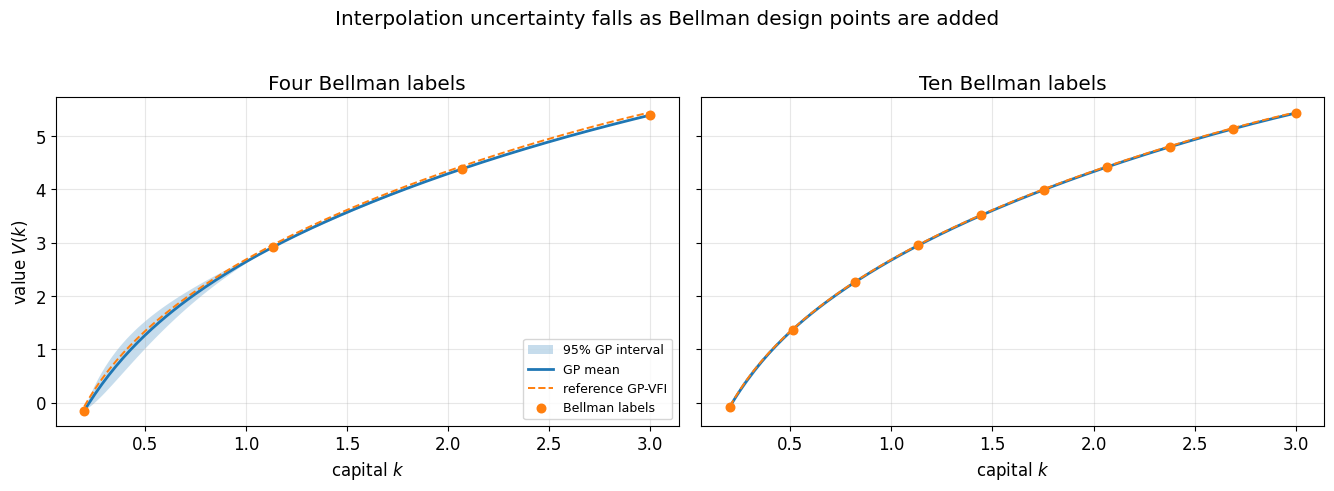

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)
for ax, result, title in [
    (axes[0], few_result, "Four Bellman labels"),
    (axes[1], more_result, "Ten Bellman labels"),
]:
    mean, std = gp_predict(result["gp"], k_eval, return_std=True)
    ax.fill_between(k_eval, mean - 1.96 * std, mean + 1.96 * std, alpha=0.25, label="95% GP interval")
    ax.plot(k_eval, mean, lw=2.0, label="GP mean")
    ax.plot(k_eval, reference_values, "--", lw=1.4, label="reference GP-VFI")
    ax.scatter(result["k_train"], result["V_train"], s=38, zorder=4, label="Bellman labels")
    ax.set_xlabel("capital $k$")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("value $V(k)$")
axes[0].legend(fontsize=9, loc="lower right")
fig.suptitle("Interpolation uncertainty falls as Bellman design points are added", y=1.02)
plt.tight_layout()
savefig("gp_vfi_few_vs_more_1d.pdf")
plt.show()


## 6. Active enrichment inside GP-VFI

The active rule is deliberately pure exploration: evaluate the GP posterior standard deviation on a candidate grid, mask points that are too close to the existing design, and add the highest-uncertainty points.  This is the cleanest notebook companion to §9.8.6 because every label is still a Bellman label.


In [10]:
active_initial = np.linspace(base_model.k_min, base_model.k_max, 6)
active_result = run_gp_vfi(
    active_initial,
    base_model,
    label="active BAL",
    max_iter=CFG["experiment_iter"],
    tol=CFG["tol"],
    hp_opt_iters=CFG["hp_opt_iters"],
    n_restarts=CFG["n_restarts"],
    adaptive=True,
    add_every=10 if RUN_MODE == "smoke" else 12,
    n_add=2,
    max_points=10,
    min_spacing=0.14,
)
def lhs_design_1d(n: int, model: GrowthModel, seed: int = 2025) -> np.ndarray:
    rng = np.random.default_rng(seed)
    if n <= 2:
        return np.linspace(model.k_min, model.k_max, n)
    n_inner = n - 2
    u = (np.arange(n_inner) + rng.random(n_inner)) / n_inner
    rng.shuffle(u)
    inner = model.k_min + u * (model.k_max - model.k_min)
    return np.sort(np.r_[model.k_min, inner, model.k_max])

lhs_result = run_gp_vfi(
    lhs_design_1d(10, base_model),
    base_model,
    label="fixed LHS",
    max_iter=CFG["experiment_iter"],
    tol=CFG["tol"],
    hp_opt_iters=CFG["hp_opt_iters"],
    n_restarts=CFG["n_restarts"],
)

print("Active points added in order:")
print(np.array2string(active_result["added_points"], precision=4, separator=", "))

def design_metrics(result: dict) -> dict:
    mean, std = gp_predict(result["gp"], k_eval, return_std=True)
    residual = bellman_residual_grid(result, k_eval)
    return {
        "points": len(result["k_train"]),
        "iterations": result["iterations"],
        "max_std": float(np.max(std)),
        "mean_std": float(np.mean(std)),
        "max_bellman_resid": float(np.max(np.abs(residual))),
        "loo_rmse": gp_loo_rmse(result["gp"], result["k_train"], result["V_train"]),
    }

metrics = {"fixed LHS": design_metrics(lhs_result), "active BAL": design_metrics(active_result)}
print("\nSame final budget: fixed LHS versus active enrichment")
print("-" * 108)
print(f"{'design':<16s} {'pts':>5s} {'iters':>6s} {'max std':>10s} {'mean std':>10s} {'max Bellman':>12s} {'LOO RMSE':>10s}")
print("-" * 108)
for name, row in metrics.items():
    print(f"{name:<16s} {row['points']:5d} {row['iterations']:6d} {row['max_std']:10.2e} {row['mean_std']:10.2e} {row['max_bellman_resid']:12.2e} {row['loo_rmse']:10.2e}")
print("-" * 108)


Active points added in order:
[0.3895, 0.5298, 1.014 , 1.1544]



Same final budget: fixed LHS versus active enrichment
------------------------------------------------------------------------------------------------------------
design             pts  iters    max std   mean std  max Bellman   LOO RMSE
------------------------------------------------------------------------------------------------------------
fixed LHS           10     36   2.85e-02   3.01e-03     5.34e-02   4.51e-02
active BAL          10     37   1.24e-02   1.43e-03     5.16e-02   1.78e-02
------------------------------------------------------------------------------------------------------------


saved: fig_gp_vfi/gp_vfi_active_learning_1d.pdf


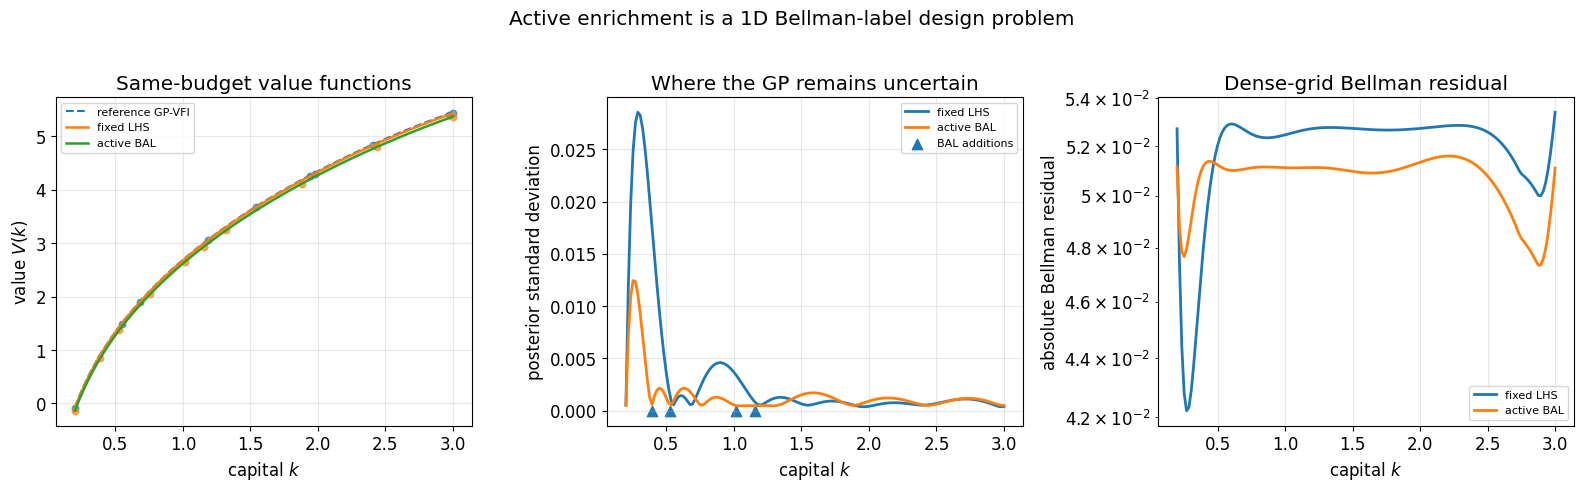

In [11]:
mean_lhs, std_lhs = gp_predict(lhs_result["gp"], k_eval, return_std=True)
mean_active, std_active = gp_predict(active_result["gp"], k_eval, return_std=True)
resid_lhs = np.abs(bellman_residual_grid(lhs_result, k_eval))
resid_active = np.abs(bellman_residual_grid(active_result, k_eval))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
ax.plot(k_eval, reference_values, "--", lw=1.5, label="reference GP-VFI")
ax.plot(k_eval, mean_lhs, lw=1.8, label="fixed LHS")
ax.plot(k_eval, mean_active, lw=1.8, label="active BAL")
ax.scatter(lhs_result["k_train"], lhs_result["V_train"], s=22, alpha=0.65)
ax.scatter(active_result["k_train"], active_result["V_train"], s=22, alpha=0.65)
ax.set_xlabel("capital $k$")
ax.set_ylabel("value $V(k)$")
ax.set_title("Same-budget value functions")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(k_eval, std_lhs, lw=2, label="fixed LHS")
ax.plot(k_eval, std_active, lw=2, label="active BAL")
if len(active_result["added_points"]) > 0:
    ax.scatter(active_result["added_points"], np.zeros_like(active_result["added_points"]), marker="^", s=55, label="BAL additions")
ax.set_xlabel("capital $k$")
ax.set_ylabel("posterior standard deviation")
ax.set_title("Where the GP remains uncertain")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

ax = axes[2]
ax.semilogy(k_eval, resid_lhs + 1e-12, lw=2, label="fixed LHS")
ax.semilogy(k_eval, resid_active + 1e-12, lw=2, label="active BAL")
ax.set_xlabel("capital $k$")
ax.set_ylabel("absolute Bellman residual")
ax.set_title("Dense-grid Bellman residual")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

fig.suptitle("Active enrichment is a 1D Bellman-label design problem", y=1.02)
plt.tight_layout()
savefig("gp_vfi_active_learning_1d.pdf")
plt.show()


saved: fig_gp_vfi/gp_vfi_diagnostics_1d.pdf


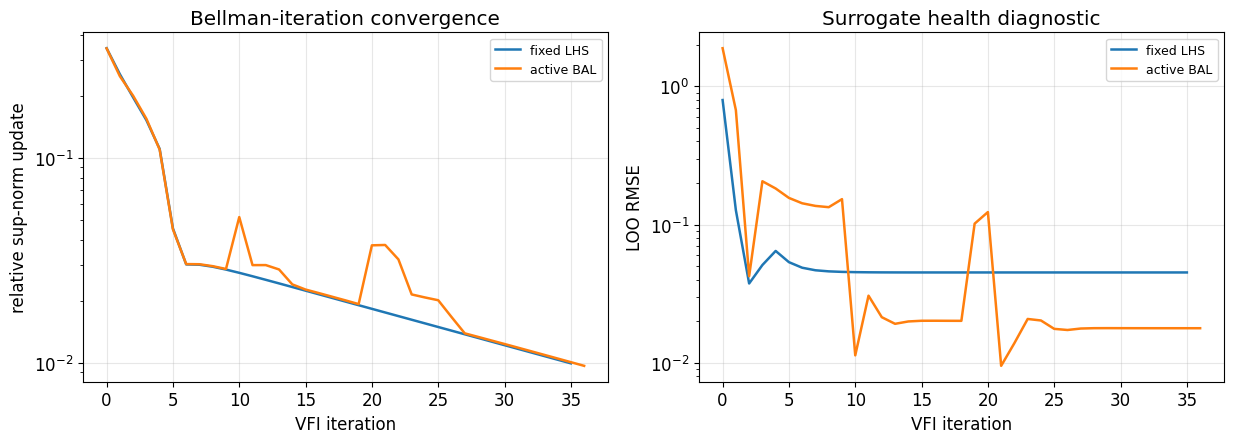

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

for result, label in [(lhs_result, "fixed LHS"), (active_result, "active BAL")]:
    axes[0].semilogy(history_array(result, "error"), lw=1.8, label=label)
    axes[1].semilogy(history_array(result, "loo_rmse"), lw=1.8, label=label)

axes[0].set_xlabel("VFI iteration")
axes[0].set_ylabel("relative sup-norm update")
axes[0].set_title("Bellman-iteration convergence")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].set_xlabel("VFI iteration")
axes[1].set_ylabel("LOO RMSE")
axes[1].set_title("Surrogate health diagnostic")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
savefig("gp_vfi_diagnostics_1d.pdf")
plt.show()


## 7. Policy recovery

After the GP has converged, recover the consumption and expected-shock savings policies by resolving the scalar Bellman maximization at validation states.


saved: fig_gp_vfi/gp_vfi_policy_1d.pdf


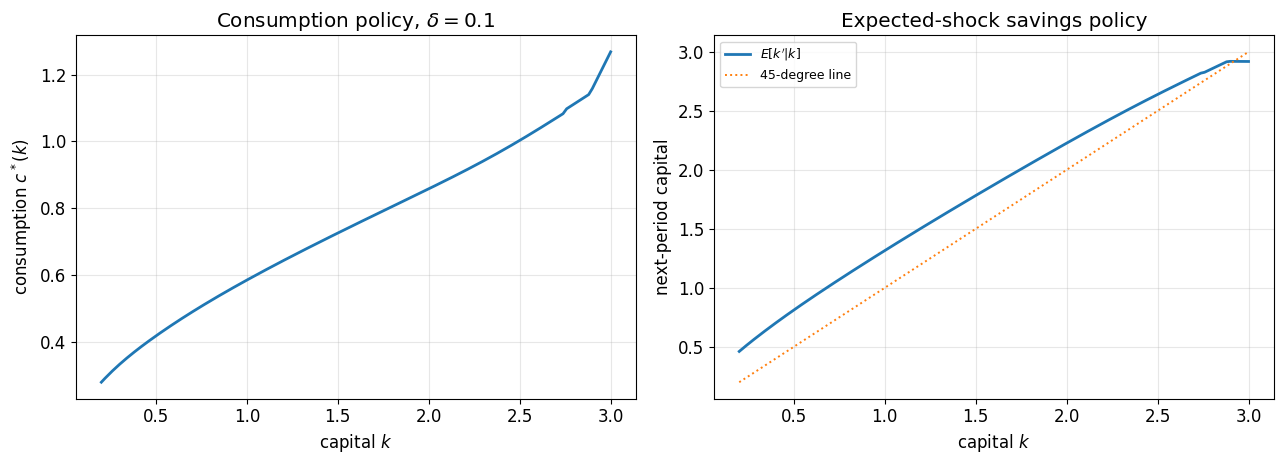

Approximate deterministic steady state from policy plot: k* = 2.9194
Consumption at that point: c* = 1.1801


In [13]:
k_policy = np.linspace(base_model.k_min, base_model.k_max, 140)
_, c_policy, k_next_policy = policy_from_gp(main_result, k_policy)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

axes[0].plot(k_policy, c_policy, lw=2)
axes[0].set_xlabel("capital $k$")
axes[0].set_ylabel("consumption $c^*(k)$")
axes[0].set_title(r"Consumption policy, $\delta=0.1$")
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_policy, k_next_policy, lw=2, label=r"$E[k'|k]$")
axes[1].plot(k_policy, k_policy, ":", lw=1.4, label="45-degree line")
axes[1].set_xlabel("capital $k$")
axes[1].set_ylabel("next-period capital")
axes[1].set_title("Expected-shock savings policy")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
savefig("gp_vfi_policy_1d.pdf")
plt.show()

idx_ss = int(np.argmin(np.abs(k_next_policy - k_policy)))
print(f"Approximate deterministic steady state from policy plot: k* = {k_policy[idx_ss]:.4f}")
print(f"Consumption at that point: c* = {c_policy[idx_ss]:.4f}")


## 8. Closed-form verification: deterministic full depreciation

The analytical Brock--Mirman formula used here is valid for the deterministic full-depreciation case \((\delta=1, z=1)\):

\[
c^*(k)=(1-\alpha\beta)A k^\alpha,\qquad
k'(k)=\alpha\beta A k^\alpha,
\]

\[
V^*(k)=\frac{\log(A(1-\alpha\beta))}{1-\beta}
+\frac{\alpha\beta\log(A\alpha\beta)}{(1-\beta)(1-\alpha\beta)}
+\frac{\alpha}{1-\alpha\beta}\log k.
\]

This cell intentionally switches off the shock.  If productivity is random and not included as a state, the deterministic closed-form policy is no longer the exact benchmark for the numerical Bellman problem.


In [14]:
verification_model = replace(
    base_model,
    delta=1.0,
    sigma=0.0,
    n_quad=1,
    k_min=0.05,
    k_max=1.00,
    name="deterministic full-depreciation verification",
)


def V_exact_delta1(k: np.ndarray | float, model: GrowthModel = verification_model) -> np.ndarray:
    k = np.asarray(k, dtype=float)
    ab = model.alpha * model.beta
    c1 = np.log(model.A * (1.0 - ab)) / (1.0 - model.beta)
    c2 = ab * np.log(model.A * ab) / ((1.0 - model.beta) * (1.0 - ab))
    c3 = model.alpha / (1.0 - ab)
    return c1 + c2 + c3 * np.log(k)


def c_exact_delta1(k: np.ndarray | float, model: GrowthModel = verification_model) -> np.ndarray:
    k = np.asarray(k, dtype=float)
    return (1.0 - model.alpha * model.beta) * model.A * k ** model.alpha


def kp_exact_delta1(k: np.ndarray | float, model: GrowthModel = verification_model) -> np.ndarray:
    k = np.asarray(k, dtype=float)
    return model.alpha * model.beta * model.A * k ** model.alpha

print(f"Analytical steady state: k* = {(verification_model.alpha * verification_model.beta * verification_model.A) ** (1/(1-verification_model.alpha)):.4f}")

verification_result = run_gp_vfi(
    np.linspace(verification_model.k_min, verification_model.k_max, CFG["verification_n"]),
    verification_model,
    label="delta=1 deterministic verification",
    max_iter=CFG["verification_iter"],
    tol=min(CFG["tol"], 2e-3),
    hp_opt_iters=CFG["hp_opt_iters"],
    n_restarts=CFG["n_restarts"],
    verbose=True,
)


Analytical steady state: k* = 0.1901

delta=1 deterministic verification: n0=14, max_iter=180, tol=0.002
iter points      VFI err     LOO RMSE
------------------------------------------


   1     14   4.9527e-01   1.1495e-01
   2     14   3.3788e-01   5.1697e-02
   3     14   3.1339e-01   2.9799e-02


  10     14   3.2739e-01   1.8514e-02


  20     14   2.1763e-01   1.8508e-02


  30     14   1.4469e-01   1.8508e-02


...

  60     14   4.2518e-02   1.8508e-02
  70     14   2.8267e-02   1.8508e-02


  80     14   1.8793e-02   1.8508e-02
  90     14   1.2494e-02   1.8508e-02


 100     14   8.3065e-03   1.8508e-02
 110     14   5.5225e-03   1.8508e-02


 120     14   3.6715e-03   1.8508e-02
 130     14   2.4409e-03   1.8508e-02


 135     14   1.9903e-03   1.8508e-02


saved: fig_gp_vfi/gp_vfi_delta1_verification.pdf


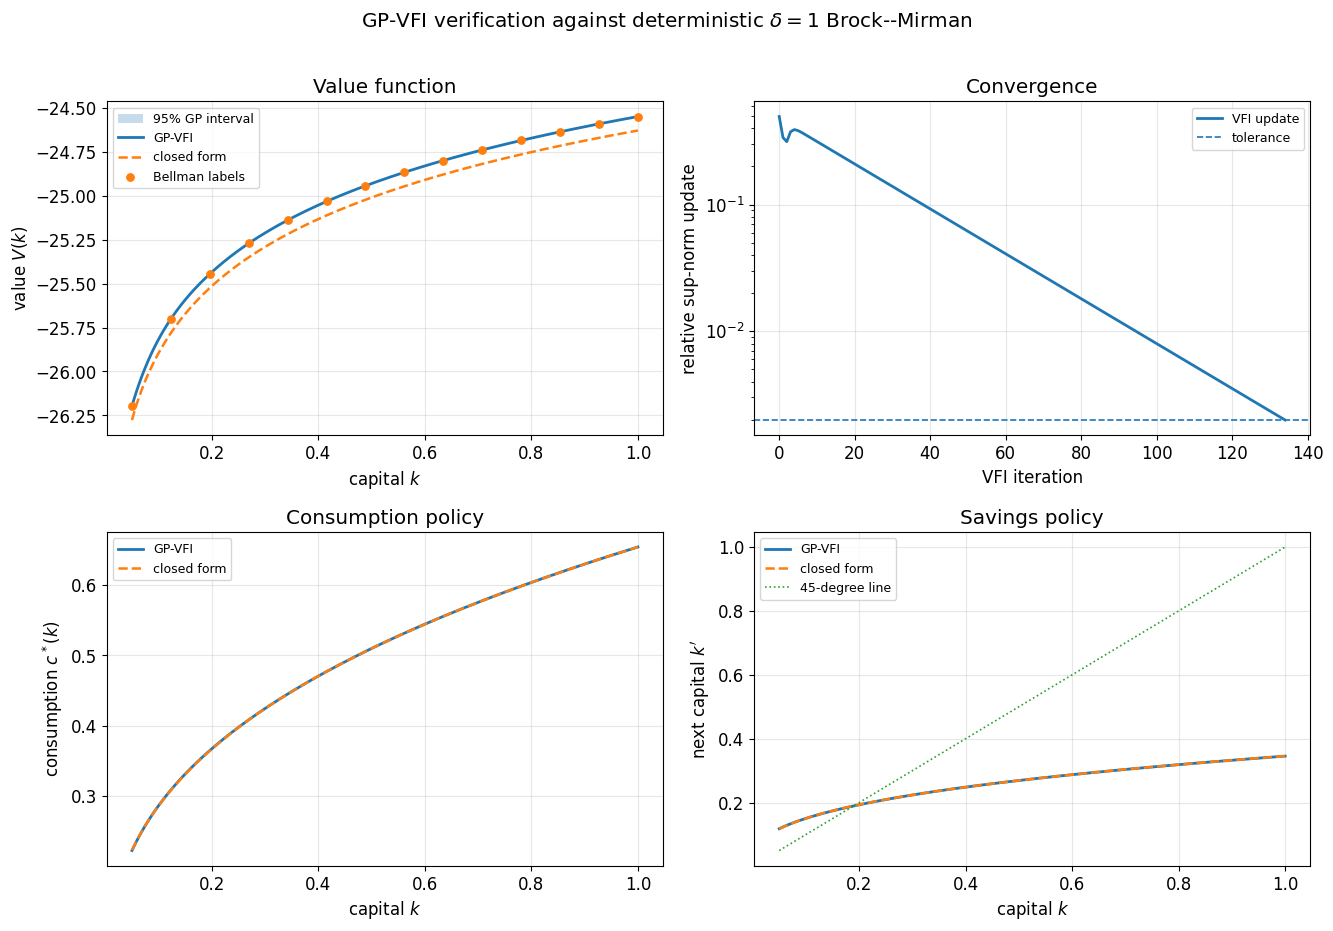

Closed-form verification report
max |V_GP - V*|   = 8.0187e-02
max |c_GP - c*|   = 6.8273e-04
max |kp_GP - kp*| = 6.8273e-04


In [15]:
k_ver = np.linspace(verification_model.k_min, verification_model.k_max, 220)
V_gp_ver, V_std_ver = gp_predict(verification_result["gp"], k_ver, return_std=True)
_, c_gp_ver, kp_gp_ver = policy_from_gp(verification_result, k_ver)

V_exact = V_exact_delta1(k_ver)
c_exact = c_exact_delta1(k_ver)
kp_exact = kp_exact_delta1(k_ver)

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.2))

ax = axes[0, 0]
ax.fill_between(k_ver, V_gp_ver - 1.96 * V_std_ver, V_gp_ver + 1.96 * V_std_ver, alpha=0.25, label="95% GP interval")
ax.plot(k_ver, V_gp_ver, lw=2, label="GP-VFI")
ax.plot(k_ver, V_exact, "--", lw=1.8, label="closed form")
ax.scatter(verification_result["k_train"], verification_result["V_train"], s=28, zorder=4, label="Bellman labels")
ax.set_xlabel("capital $k$")
ax.set_ylabel("value $V(k)$")
ax.set_title("Value function")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

ax = axes[0, 1]
ax.semilogy(history_array(verification_result, "error"), lw=2, label="VFI update")
ax.axhline(min(CFG["tol"], 2e-3), ls="--", lw=1.2, label="tolerance")
ax.set_xlabel("VFI iteration")
ax.set_ylabel("relative sup-norm update")
ax.set_title("Convergence")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

ax = axes[1, 0]
ax.plot(k_ver, c_gp_ver, lw=2, label="GP-VFI")
ax.plot(k_ver, c_exact, "--", lw=1.8, label="closed form")
ax.set_xlabel("capital $k$")
ax.set_ylabel("consumption $c^*(k)$")
ax.set_title("Consumption policy")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

ax = axes[1, 1]
ax.plot(k_ver, kp_gp_ver, lw=2, label="GP-VFI")
ax.plot(k_ver, kp_exact, "--", lw=1.8, label="closed form")
ax.plot(k_ver, k_ver, ":", lw=1.2, label="45-degree line")
ax.set_xlabel("capital $k$")
ax.set_ylabel("next capital $k'$")
ax.set_title("Savings policy")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

fig.suptitle(r"GP-VFI verification against deterministic $\delta=1$ Brock--Mirman", y=1.01)
plt.tight_layout()
savefig("gp_vfi_delta1_verification.pdf")
plt.show()

V_err = float(np.max(np.abs(V_gp_ver - V_exact)))
c_err = float(np.max(np.abs(c_gp_ver - c_exact)))
kp_err = float(np.max(np.abs(kp_gp_ver - kp_exact)))
print("=" * 60)
print("Closed-form verification report")
print("=" * 60)
print(f"max |V_GP - V*|   = {V_err:.4e}")
print(f"max |c_GP - c*|   = {c_err:.4e}")
print(f"max |kp_GP - kp*| = {kp_err:.4e}")
print("=" * 60)

if RUN_MODE == "smoke":
    assert c_err < 0.15, f"Smoke check failed: consumption error {c_err:.3f} exceeds 0.15"
else:
    assert c_err < 0.06, f"Verification failed: consumption error {c_err:.3f} exceeds 0.06"


## 9. What happened to the multidimensional toy?

I would not keep the additive separable two-dimensional target in the script.  The function

\[
V_2(k_1,k_2)=V^*(k_1)+V^*(k_2)
\]

is useful as a generic GP interpolation exercise, but it does not contain a Bellman maximization, a two-dimensional control, a transition kernel, or an active subspace.  In a VFI section it therefore risks teaching the wrong lesson: students may read the figure as evidence for multidimensional dynamic programming, while it is only evidence that posterior-variance sampling fills holes in a two-dimensional design.

For the chapter, the cleaner route is:

- Keep this notebook as the 1D GP-VFI implementation.
- Use the active 1D figure above as the notebook-generated figure for §9.8.6.
- Discuss the high-dimensional ASGP results of Scheidegger and Bilionis as literature in §9.8.7.
- Put any standalone 2D interpolation demos in the active-subspace notebooks, not in the VFI notebook.

That separation gives the section a sharper narrative: exact DP contraction, GP interpolation error, LOO diagnostics, active enrichment, and then a literature bridge to active subspaces for large \(D\).


## Summary

The notebook now supports the script with one coherent empirical story:

1. **GP-VFI is a Bellman solver in 1D.** Every plotted training label is generated by a Bellman maximization.
2. **GP uncertainty is useful but should be interpreted as interpolation uncertainty.** It is not a full statement about policy uncertainty unless propagated through the argmax.
3. **LOO RMSE separates surrogate health from Bellman convergence.** A good surrogate can still be far from the fixed point.
4. **Active enrichment belongs inside the VFI loop.** The acquisition rule is pure exploration because the goal is uniform value-function interpolation, not objective-function maximization.
5. **The closed-form check is deterministic full-depreciation Brock--Mirman.** The notebook makes this explicit by setting \(\sigma=0\) for the verification run.
